# Análisis y Predicción de la Calidad del Aire en el GAM

**Institución:** Colegio Universitario de Cartago  
**Curso:** Big Data (BD-143) — III Cuatrimestre 2025  
**Profesor:** Osvaldo González Chaves  
**Estudiantes:** Mariana Méndez | Claret Rodríguez  

---

## Descripción General

Este notebook presenta el análisis exploratorio completo, visualizaciones y 
resultados del modelo de Machine Learning desarrollado para predecir la 
categoría de calidad del aire en el Gran Área Metropolitana (GAM) de Costa Rica.

La pregunta central del proyecto es:

> **¿Cuándo hay más vehículos en circulación, hay peor calidad del aire en el GAM?**

Para responderla se integran tres fuentes de datos:
- **Flujo vehicular** de la Ruta 27 (ARESEP) — 2009 a 2025
- **Calidad del aire** (PM2.5, PM10, NO2, CO, Ozono) — Open-Meteo API
- **Clima histórico** (temperatura, humedad, viento) — Open-Meteo Archive API

---

## Variable Objetivo

Se predice la **categoría ICA** (Índice Costarricense de Calidad del Aire):

| Categoría | PM2.5 (μg/m³) | Descripción |
|-----------|---------------|-------------|
|  Buena | 0 — 12 | Calidad del aire satisfactoria |
|  Moderada | 12 — 35 | Calidad aceptable |
|  Mala | 35 — 55 | Grupos sensibles pueden verse afectados |
|  Muy Mala | +55 | Toda la población puede verse afectada |

In [1]:
# ─────────────────────────────────────────────────────────────
# Importaciones y configuración del entorno
# ─────────────────────────────────────────────────────────────

import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Agregar src al path para importar módulos del proyecto
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Importar clases del proyecto
from basedatos.gestor_base_datos import GestorBaseDatos
from eda.procesador_eda import ProcesadorEDA
from visualizacion.visualizador import Visualizador
from modelos.modelo_ml import ModeloML

print(" Librerías importadas correctamente")
print(f" Directorio de trabajo: {os.getcwd()}")

 Librerías importadas correctamente
 Directorio de trabajo: C:\Users\mari2\Desktop\Progra 2\Proyecto Final\notebooks


---
## 1. Carga de Datos desde SQL Server

Los datos fueron previamente procesados y almacenados en una base de datos 
**SQL Server** llamada `CalidadAireGAM`. Se tienen tres tablas principales:

| Tabla | Descripción | Registros |
|-------|-------------|-----------|
| `flujo_vehicular` | Flujo vehicular mensual Ruta 27 (ARESEP) 2014-2024 | 1,440 |
| `calidad_aire` | PM2.5, PM10, NO2, CO, Ozono — Open-Meteo API 2022-2024 | 29 |
| `clima` | Temperatura, humedad, velocidad del viento 2022-2024 | 29 |

A continuación se cargan los datos directamente desde la base de datos usando 
la clase `GestorBaseDatos`.

In [2]:
# ─────────────────────────────────────────────────────────────
# CELDA 4: Carga de datos desde SQL Server
# ─────────────────────────────────────────────────────────────

# Inicializar conexión a la base de datos
gestor_bd = GestorBaseDatos()

# Cargar las tres tablas
df_flujo = gestor_bd.consultar("SELECT * FROM flujo_vehicular")
df_aire = gestor_bd.consultar("SELECT * FROM calidad_aire")
df_clima = gestor_bd.consultar("SELECT * FROM clima")

# Mostrar resumen de cada tabla
print("=" * 55)
print(" DATOS CARGADOS DESDE SQL SERVER")
print("=" * 55)
print(f"\n Flujo Vehicular: {df_flujo.shape[0]} filas x {df_flujo.shape[1]} columnas")
print(f"  Calidad del Aire: {df_aire.shape[0]} filas x {df_aire.shape[1]} columnas")
print(f"  Clima: {df_clima.shape[0]} filas x {df_clima.shape[1]} columnas")

print("\n--- Vista previa: Flujo Vehicular ---")
display(df_flujo.head())

print("\n--- Vista previa: Calidad del Aire ---")
display(df_aire.head())

print("\n--- Vista previa: Clima ---")
display(df_clima.head())

[GestorBaseDatos] Conexion exitosa a SQL Server.
[GestorBaseDatos] Consulta ejecutada: 1440 filas.
[GestorBaseDatos] Consulta ejecutada: 29 filas.
[GestorBaseDatos] Consulta ejecutada: 29 filas.
 DATOS CARGADOS DESDE SQL SERVER

 Flujo Vehicular: 1440 filas x 11 columnas
  Calidad del Aire: 29 filas x 9 columnas
  Clima: 29 filas x 7 columnas

--- Vista previa: Flujo Vehicular ---


,id,anio,mes,punto_conteo,liviano,dos_tres_ejes,cuatro_ejes,cinco_mas_ejes,autobus,total,ubicacion
0,1,2014,Enero,10540,1945773,19721,16070,26142,16887,2024593,Santa Ana Ciudad Colon
1,2,2014,Enero,22450,314226,11148,3034,8939,11183,348530,Ciudad Colon
2,3,2014,Enero,2900,3008295,31763,38483,32554,25662,3136757,Escazu
3,4,2014,Enero,30620,634028,16603,5437,21221,11121,688410,Castro Madriz Sector A
4,5,2014,Enero,31550,132063,4117,1316,740,1579,139815,Castro Madriz Sector B



--- Vista previa: Calidad del Aire ---


,id,anio,mes_num,pm2_5,pm10,nitrogen_dioxide,carbon_monoxide,ozone,mes
0,1,2022,8,8.59,12.56,26.78,340.50,20.10,Agosto
1,2,2022,9,10.04,14.44,29.03,402.22,17.64,Setiembre
2,3,2022,10,7.54,10.89,24.58,278.03,16.62,Octubre
3,4,2022,11,7.28,10.50,27.71,281.87,14.59,Noviembre
4,5,2022,12,5.81,8.51,22.21,192.69,27.86,Diciembre



--- Vista previa: Clima ---


,id,anio,mes_num,temperature_2m,relative_humidity_2m,windspeed_10m,mes
0,1,2022,8,19.28,86.69,6.14,Agosto
1,2,2022,9,18.78,91.01,5.08,Setiembre
2,3,2022,10,19.13,87.02,6.10,Octubre
3,4,2022,11,18.89,88.33,6.12,Noviembre
4,5,2022,12,18.93,75.28,10.57,Diciembre


## 2. Análisis Exploratorio de Datos (EDA)

En esta sección se realiza el análisis exploratorio de los datos con el objetivo de comprender su estructura, calidad y comportamiento.

Se analizan tres conjuntos de datos principales:

- **Flujo vehicular**
- **Calidad del aire**
- **Variables climáticas**

Los cuales fueron previamente almacenados en una base de datos SQL Server.

A través de la clase `ProcesadorEDA`, se llevan a cabo los siguientes procesos:

### Procesos realizados

- Análisis general de cada dataset (dimensiones, tipos de datos y estadísticas descriptivas)
- Identificación de valores nulos
- Análisis temporal del comportamiento de las variables
- Evaluación de la relación entre el flujo vehicular y los niveles de contaminación

### Objetivo del análisis

Este análisis permite obtener una visión inicial de los datos y sirve como base para las etapas posteriores de visualización y modelado predictivo.

In [4]:
# Crear instancia del procesador EDA
eda = ProcesadorEDA()

# Asignar los DataFrames ya cargados desde SQL Server
eda.df_flujo = df_flujo
eda.df_aire = df_aire
eda.df_clima = df_clima

# =========================================
# RESUMEN GENERAL DE LOS DATOS
# =========================================
eda.resumen_general(eda.df_flujo, "Flujo Vehicular")
eda.resumen_general(eda.df_aire, "Calidad del Aire")
eda.resumen_general(eda.df_clima, "Clima")

# =========================================
# ANÁLISIS DE VALORES NULOS
# =========================================
eda.valores_nulos(eda.df_flujo, "Flujo Vehicular")
eda.valores_nulos(eda.df_aire, "Calidad del Aire")
eda.valores_nulos(eda.df_clima, "Clima")

# =========================================
# ANÁLISIS TEMPORAL
# =========================================
df_flujo_anio = eda.flujo_por_anio()
df_aire_anio = eda.promedio_aire_por_anio()
df_clima_anio = eda.promedio_clima_por_anio()

# =========================================
# CORRELACIÓN ENTRE VARIABLES
# =========================================
correlacion = eda.correlacion_flujo_aire()

[GestorBaseDatos] Conexion exitosa a SQL Server.

 RESUMEN: Flujo Vehicular
Filas: 1440 | Columnas: 11

Columnas: ['id', 'anio', 'mes', 'punto_conteo', 'liviano', 'dos_tres_ejes', 'cuatro_ejes', 'cinco_mas_ejes', 'autobus', 'total', 'ubicacion']

Tipos de datos:
id                int64
anio              int64
mes                 str
punto_conteo      int64
liviano           int64
dos_tres_ejes     int64
cuatro_ejes       int64
cinco_mas_ejes    int64
autobus           int64
total             int64
ubicacion           str
dtype: object

Estadísticas descriptivas:
                id         anio  punto_conteo       liviano  dos_tres_ejes  \
count  1440.000000  1440.000000   1440.000000  1.440000e+03    1440.000000   
mean    720.500000  2018.900000  34290.416667  8.873158e+05   35613.036111   
std     415.836506     3.301146  25695.329838  8.086347e+05   34730.512952   
min       1.000000  2014.000000    500.000000  9.587200e+04    3123.000000   
25%     360.750000  2016.000000   9680.00

### Resultados del Análisis Exploratorio

A partir del análisis realizado, se pueden destacar los siguientes hallazgos:

#### Estructura de los datos
- El dataset de flujo vehicular es el más grande, con 1440 registros, mientras que los datasets de calidad del aire y clima contienen 29 registros cada uno.
- Esto indica que los datos de aire y clima están agregados a nivel mensual, mientras que el flujo vehicular tiene mayor detalle.

#### Calidad de los datos
- No se encontraron valores nulos en ninguno de los datasets, lo cual facilita el análisis y modelado posterior.
- Las variables presentan tipos de datos adecuados (enteros y flotantes), por lo que no se requieren transformaciones adicionales en esta etapa.

#### Análisis temporal
- El flujo vehicular muestra variaciones a lo largo de los años, con un aumento general hasta 2019 y una disminución en años posteriores.
- Los contaminantes como PM2.5 y NO2 presentan variaciones moderadas entre los años 2022 y 2024.
- Las variables climáticas se mantienen relativamente estables, con ligeras variaciones en temperatura, humedad y velocidad del viento.

#### Correlación entre variables
- Se observa una correlación positiva entre el flujo vehicular y el PM2.5 (0.30), lo que sugiere que a mayor cantidad de vehículos, mayor concentración de partículas contaminantes.
- También existe una relación positiva entre PM2.5 y dióxido de nitrógeno (NO2).
- El ozono presenta una correlación negativa con el NO2, lo cual es consistente con procesos atmosféricos conocidos.

#### Conclusión del EDA
En general, los resultados sugieren que el flujo vehicular tiene una influencia moderada en la calidad del aire, aunque no es el único factor determinante.  
Las condiciones climáticas también juegan un papel importante en la dispersión y concentración de contaminantes.

Este análisis servirá como base para la construcción del modelo de Machine Learning en la siguiente sección.

## 3. Visualización de Datos

En esta sección se presentan diferentes visualizaciones con el objetivo de analizar el comportamiento del flujo vehicular, la calidad del aire y las variables climáticas.

Las gráficas permiten identificar patrones, tendencias y relaciones entre las variables, facilitando la interpretación de los datos obtenidos en el análisis exploratorio.

### Visualizaciones realizadas

- Flujo vehicular total por año
- Flujo vehicular promedio por mes
- Niveles de PM2.5 por mes
- Comparación de contaminantes por año
- Mapa de correlación entre variables
- Tendencia de temperatura
- Mapa geográfico de la Ruta 27

Estas visualizaciones ayudan a comprender mejor la relación entre el tráfico vehicular y la calidad del aire en el GAM.

[GestorBaseDatos] Conexion exitosa a SQL Server.


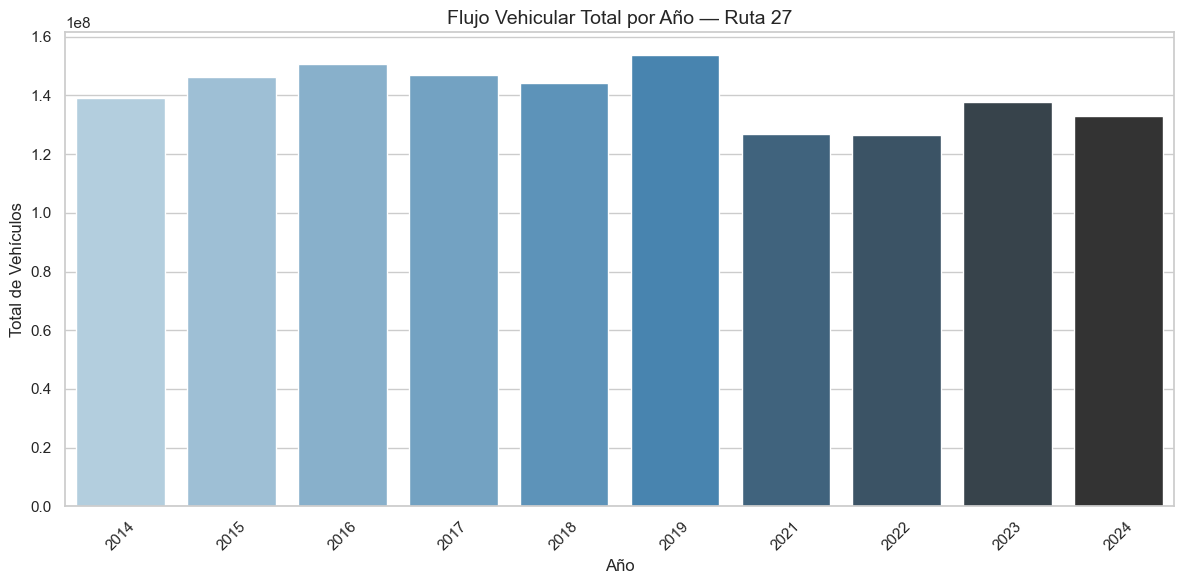

[Visualizador] Gráfico flujo por año generado.


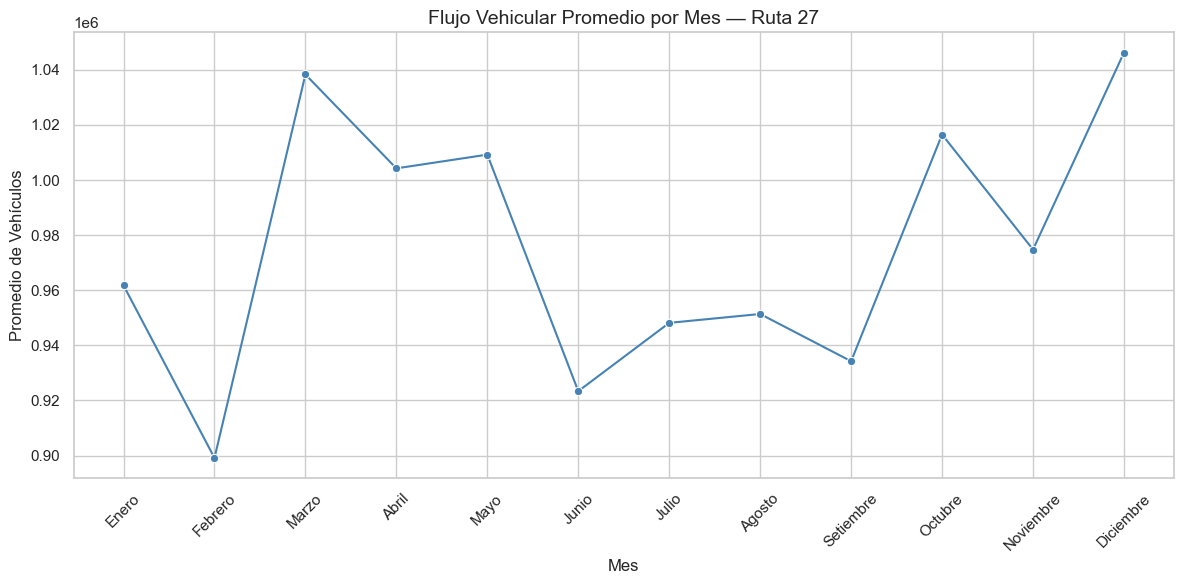

[Visualizador] Gráfico flujo por mes generado.


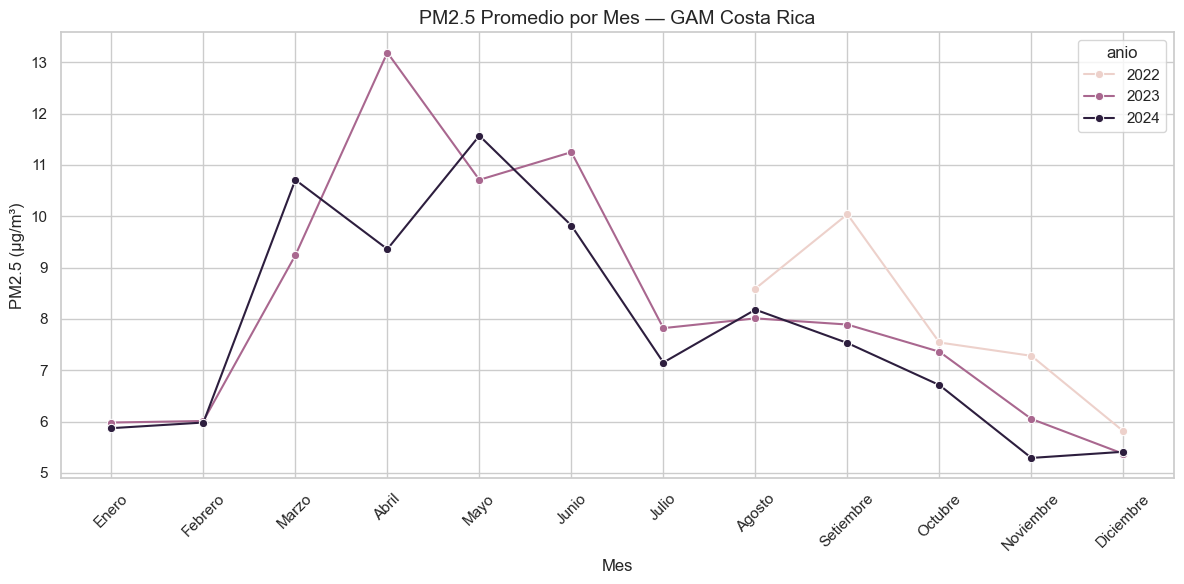

[Visualizador] Gráfico PM2.5 por mes generado.


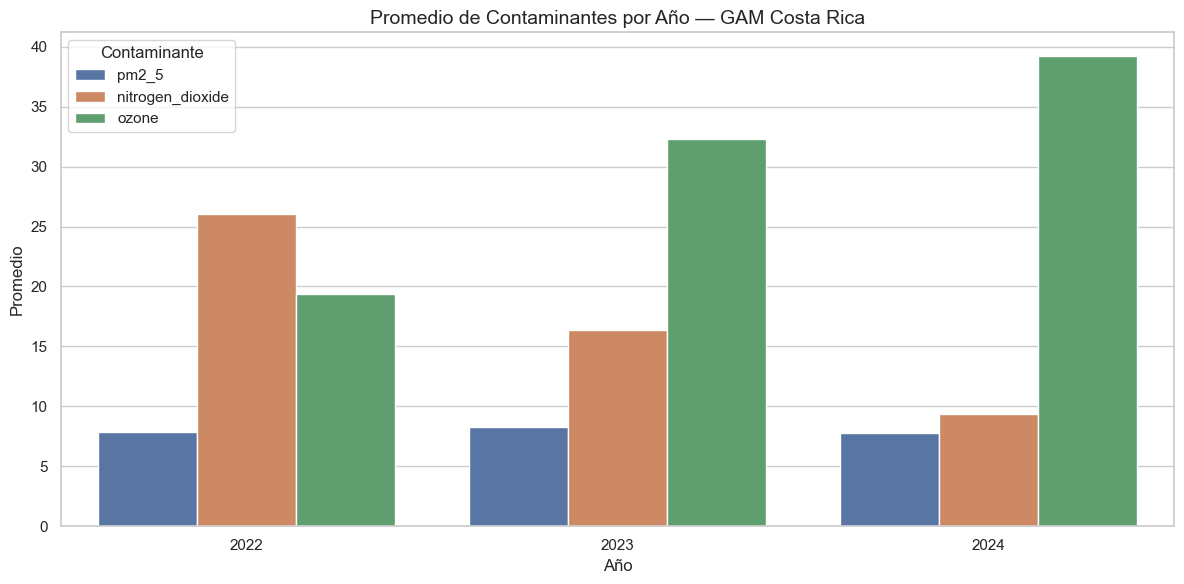

[Visualizador] Gráfico contaminantes por año generado.


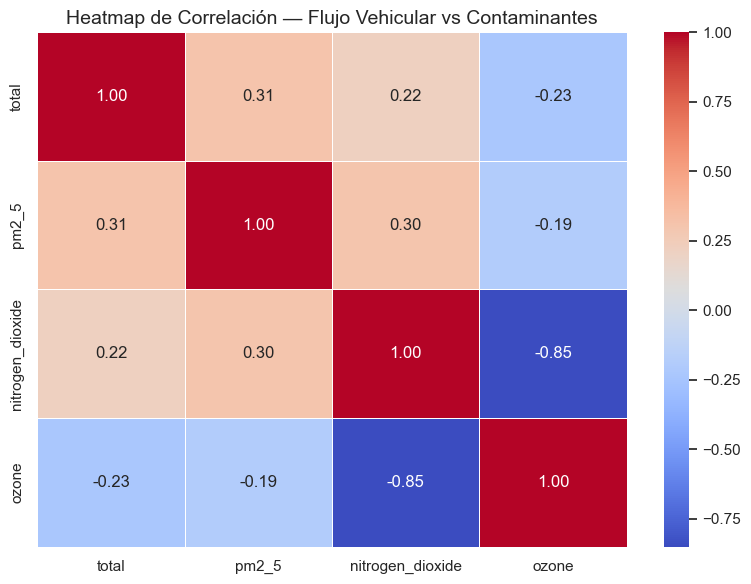

[Visualizador] Heatmap de correlación generado.


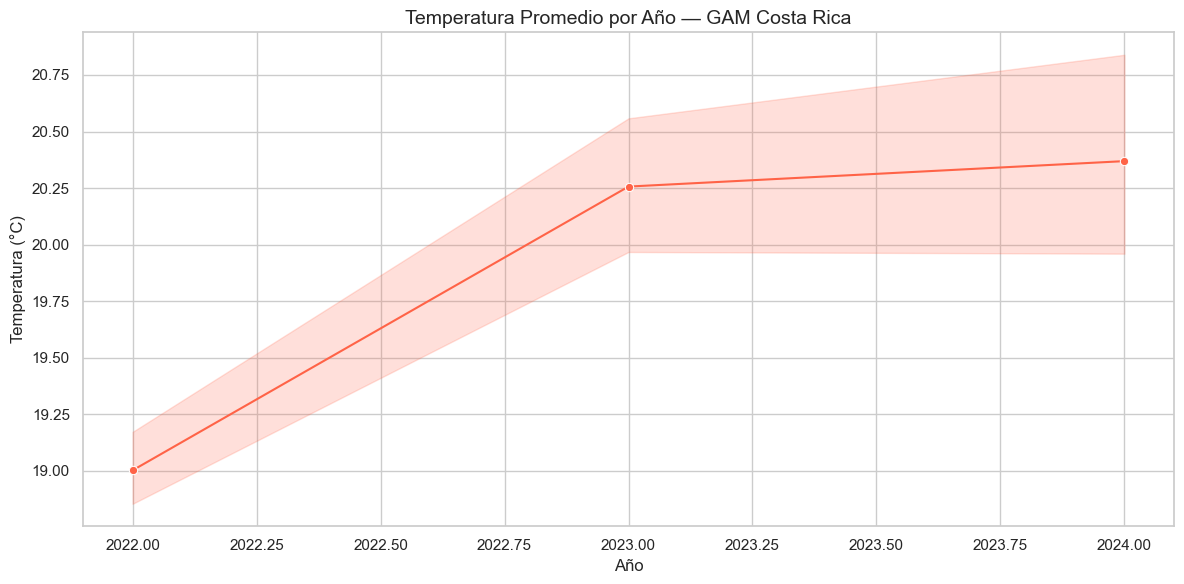

[Visualizador] Gráfico temperatura generado.
[Visualizador] Mapa Ruta 27 guardado.


In [5]:
viz = Visualizador()

# Asignar los datos ya cargados
viz.df_flujo = df_flujo
viz.df_aire = df_aire
viz.df_clima = df_clima

# =========================================
# GRÁFICOS
# =========================================

viz.grafico_flujo_por_anio()
viz.grafico_flujo_por_mes()
viz.grafico_pm25_por_mes()
viz.grafico_contaminantes_por_anio()
viz.heatmap_correlacion()
viz.grafico_temperatura_por_anio()

# =========================================
# MAPA
# =========================================

mapa = viz.mapa_ruta_27()
mapa

### Interpretación de las visualizaciones

A partir de las gráficas generadas, se pueden observar los siguientes aspectos:

- El flujo vehicular presenta variaciones importantes a lo largo de los años, evidenciando cambios en la movilidad.
- A nivel mensual, se identifican patrones estacionales en la circulación de vehículos.
- Los niveles de PM2.5 muestran fluctuaciones moderadas, lo que sugiere variaciones en la calidad del aire.
- El heatmap de correlación confirma una relación positiva entre el flujo vehicular y algunos contaminantes.
- La temperatura se mantiene relativamente estable, aunque influye en la dispersión de contaminantes.
- El mapa permite ubicar geográficamente la Ruta 27 y los puntos de análisis.

En conjunto, estas visualizaciones refuerzan la hipótesis de que el flujo vehicular tiene un impacto en la calidad del aire, aunque no es el único factor determinante.

## 4. Modelo de Machine Learning

En esta sección se desarrolla un modelo de clasificación con el objetivo de predecir la categoría de calidad del aire (ICA) a partir de variables relacionadas con el flujo vehicular y las condiciones climáticas.

Se utilizan técnicas de aprendizaje supervisado, donde el modelo aprende patrones a partir de los datos históricos para posteriormente realizar predicciones.

### Objetivo del modelo

Predecir la categoría del Índice de Calidad del Aire (ICA) utilizando variables como:

- Flujo vehicular total
- Temperatura
- Humedad relativa
- Velocidad del viento

### Enfoque

Se entrenan y evalúan distintos modelos de Machine Learning para identificar cuál ofrece mejor desempeño en la clasificación.

In [6]:
modelo = ModeloML()

# =========================================
# PREPARACIÓN DE DATOS
# =========================================
df_modelo = modelo.cargar_y_preparar_datos()

# División en entrenamiento y prueba
modelo.dividir_datos()

# =========================================
# ENTRENAMIENTO DE MODELOS
# =========================================
modelo.entrenar_random_forest()
modelo.entrenar_arbol_decision()
modelo.entrenar_knn()

# =========================================
# COMPARACIÓN DE MODELOS
# =========================================
modelo.comparar_modelos()

# =========================================
# VALIDACIÓN Y OPTIMIZACIÓN
# =========================================
modelo.cross_validacion()
modelo.optimizar_random_forest()

# =========================================
# EJEMPLO DE PREDICCIÓN
# =========================================
modelo.predecir_nuevo(
    total_vehiculos=950000,
    pm2_5=8.5,
    nitrogen_dioxide=15.2,
    ozone=32.1,
    temperature_2m=20.5,
    relative_humidity_2m=78.0,
    windspeed_10m=7.5
)

[GestorBaseDatos] Conexion exitosa a SQL Server.
[GestorBaseDatos] Consulta ejecutada: 120 filas.
[GestorBaseDatos] Consulta ejecutada: 29 filas.
[GestorBaseDatos] Consulta ejecutada: 29 filas.
[ModeloML] Dataset preparado: 29 filas, 10 columnas
[ModeloML] Distribución ICA:
categoria_ica
Buena       28
Moderada     1
Name: count, dtype: int64
[ModeloML] Entrenamiento: 23 muestras | Prueba: 6 muestras

 RANDOM FOREST — Accuracy: 83.33%
              precision    recall  f1-score   support

       Buena       0.83      1.00      0.91         5
    Moderada       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6


 ÁRBOL DE DECISIÓN — Accuracy: 83.33%
              precision    recall  f1-score   support

       Buena       0.83      1.00      0.91         5
    Moderada       0.00      0.00      0.00         1

    accuracy                   

'Buena'

### Resultados del modelo

Los modelos entrenados presentan un accuracy de aproximadamente 83%, lo que inicialmente podría interpretarse como un buen desempeño.

Sin embargo, al analizar el reporte de clasificación se observa que el dataset está altamente desbalanceado:

- La mayoría de los registros pertenecen a la categoría "Buena"
- Solo existe una observación en la categoría "Moderada"

Debido a esto, los modelos tienden a predecir principalmente la clase mayoritaria, logrando una alta precisión general pero sin capacidad de identificar correctamente la clase minoritaria.

### Análisis

Los resultados muestran que:

- El modelo clasifica correctamente la mayoría de los casos "Buena"
- No logra predecir correctamente la categoría "Moderada"
- El accuracy no es una métrica suficiente en este caso debido al desbalance de datos

La validación cruzada presenta valores altos, pero estos resultados también están influenciados por la distribución desigual de las clases.

### Conclusión

El modelo evidencia que existe cierta relación entre las variables analizadas y la calidad del aire.

Sin embargo, debido al tamaño reducido del dataset y al desbalance de clases, los resultados deben interpretarse con precaución.

Para mejorar el modelo, sería necesario contar con más datos y una distribución más equilibrada entre las categorías del ICA.


## 5. Conclusiones

A partir del análisis realizado, se puede concluir que existe una relación entre el flujo vehicular y la calidad del aire en el Gran Área Metropolitana (GAM).

El análisis exploratorio y las visualizaciones permitieron identificar patrones en los datos, mientras que el modelo de Machine Learning mostró que variables como el flujo vehicular y las condiciones climáticas influyen en la calidad del aire.

Sin embargo, los resultados del modelo deben interpretarse con precaución debido a dos factores importantes:

- El tamaño reducido del dataset
- El desbalance en la variable objetivo (predominio de la categoría "Buena")

Esto limita la capacidad del modelo para predecir correctamente otras categorías de calidad del aire.

En general, el proyecto demuestra cómo el uso de herramientas de análisis de datos y Machine Learning permite comprender mejor fenómenos ambientales y su relación con la movilidad urbana.

### Limitaciones del proyecto

- Tamaño reducido del dataset
- Desbalance en las clases del ICA
- Falta de más variables ambientales o geográficas

### Trabajo futuro

- Incorporar más datos históricos
- Balancear el dataset
- Probar modelos más avanzados